In [1]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import stim_plots

import sys
sys.path.append("../utils/")
import helpers
import format_stim_data
import scipy.io
import os

In [2]:
''' set paths '''
data_folder = f"../data/antidromic_stim/"

# bird names
bird_ids = os.listdir(data_folder)
bird_id = 'LIM83' # example bird

save_folder = f"../figures/antidromic_hpc_to_lhy/{bird_id}/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)

save folder exists


In [19]:
# session IDs
sessions = os.listdir(f"{data_folder}{bird_id}")
ex_session = sessions[8]
print(f'{ex_session[15:22]}')

16_14_4


In [20]:
''' load and format the data '''
voltage, timestamps = format_stim_data.load_stim(data_folder, bird_id, ex_session)

# bin by time for plotting
dt = 0.0001
v, t = format_stim_data.bin_by_time(voltage, timestamps, dt=dt)

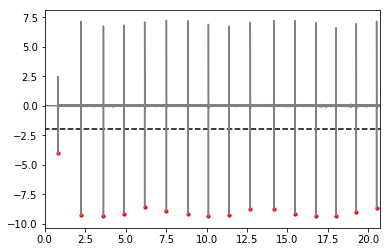

In [21]:
from scipy.signal import find_peaks

min_thresh=2
t_max = np.max(timestamps)

# find the stimulation artifact
stim_idx, _ = find_peaks(-voltage, height=min_thresh, distance=10000)

# sanity check
f, ax = plt.subplots(1, 1)
ax.plot(timestamps, voltage, 'gray')
xlim = ax.get_xlim()

ax.hlines(-min_thresh, xlim[0], xlim[1], 
          colors='k', linestyles='dashed')
ax.scatter(timestamps[stim_idx], 
           voltage[stim_idx], 
           c='r', s=10)

ax.set_xlim([0, t_max])
# ax.set_ylim([-0.5, 0.25])

plt.show()

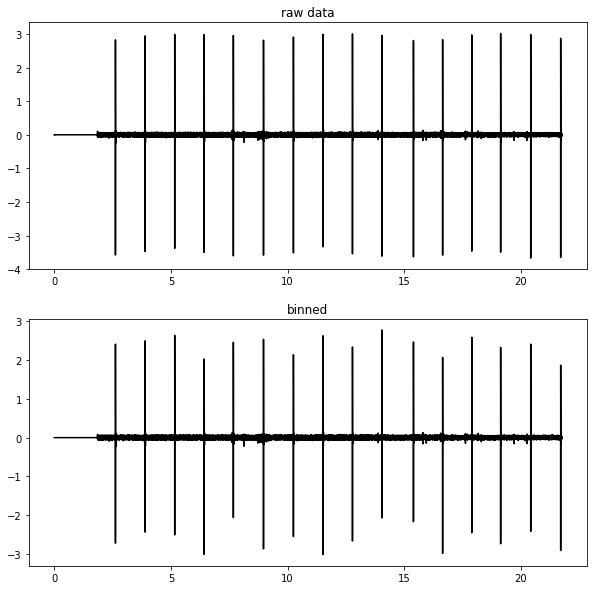

In [6]:
f, ax = plt.subplots(2, 1, figsize=(10,10))

''' plot the raw data '''
ax[0].plot(timestamps, voltage, 'k')
# ax[0].set_xlim([4.65, 4.85])
# ax[0].set_ylim([-2.5, 2.5])
ax[0].set_title('raw data')

''' plot the binned data '''
ax[1].plot(t, v, 'k')
# ax[1].set_xlim([4.65, 4.85])
# ax[1].set_ylim([-2.5, 2.5])
ax[1].set_title('binned')

plt.show()

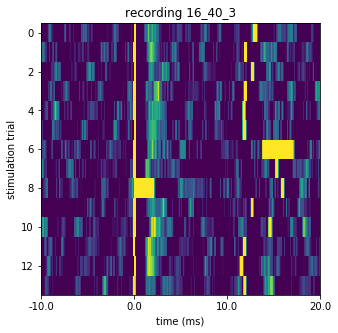

In [7]:
''' plot all stimulation trials for this session '''
f, ax = stim_plots.plot_stim_trials(v, t, dt, before_t=0.01, after_t=0.02)
ax.set_title(f'recording {ex_session[15:22]}')

# f.savefig(f'{save_folder}{ex_session[15:22]}_responses.png', dpi=600, bbox_inches='tight')
plt.show()

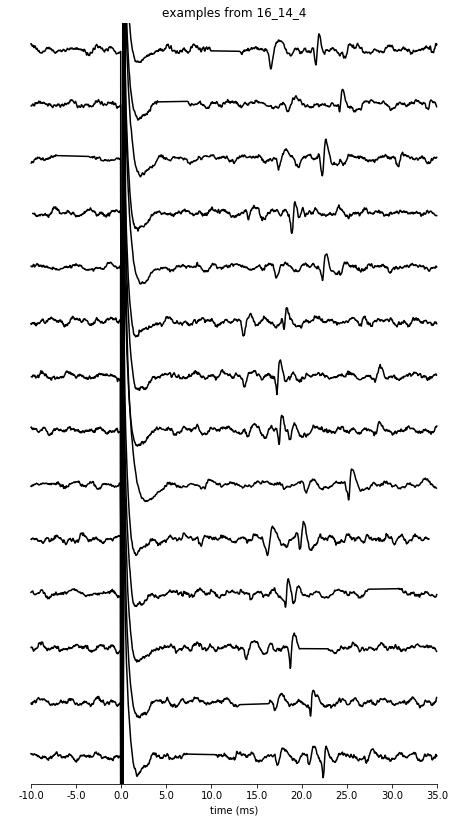

In [25]:
''' plot traces for example stim events '''
# ex_stim = np.asarray((0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 14))
f, ax = stim_plots.plot_ex_traces(voltage, timestamps, #ex_stim,
                                  before_t=0.01, after_t=0.035)
ax.set_title(f'examples from {ex_session[15:22]}')

f.savefig(f'{save_folder}example_traces_{ex_session[15:22]}.png', dpi=600, bbox_inches='tight')
plt.show()

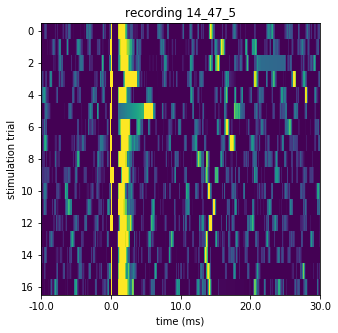

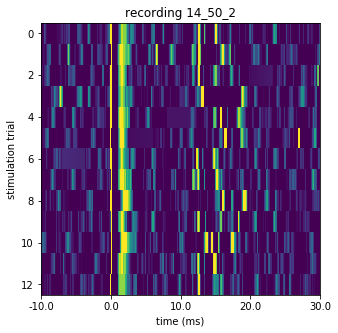

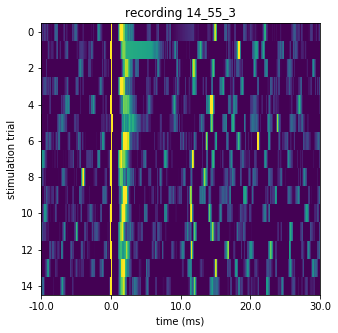

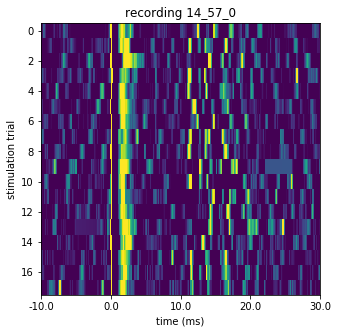

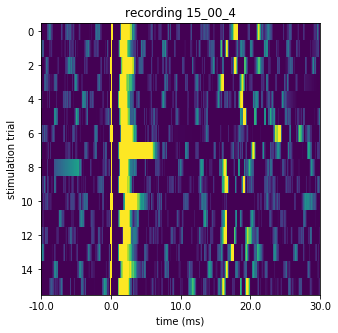

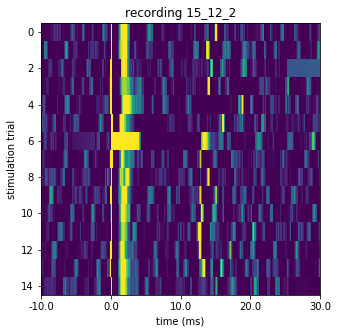

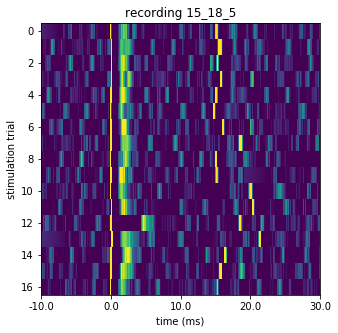

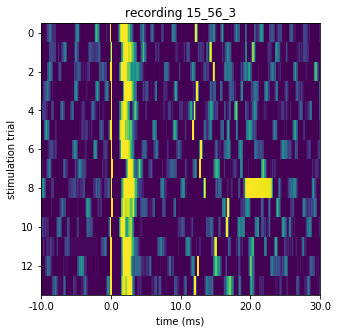

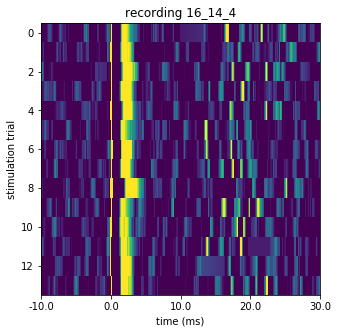

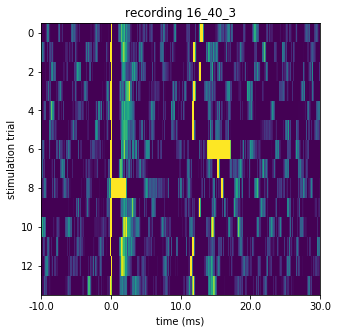

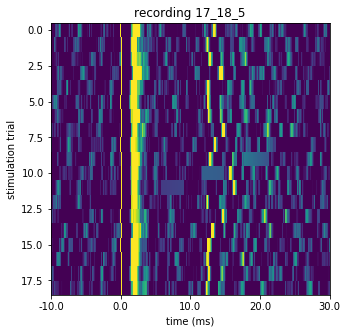

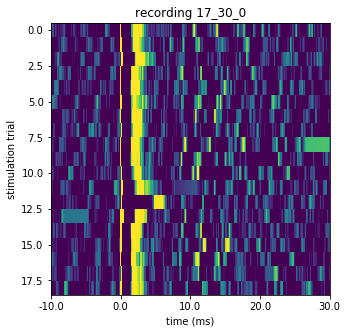

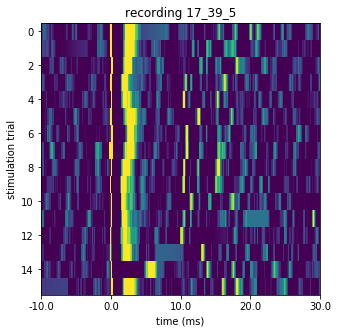

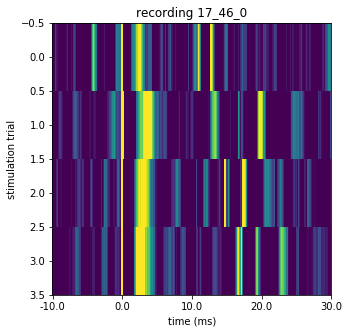

In [9]:
''' get the heatmaps for all recordings '''
for s_id in sessions:
    # load and format the data
    voltage, timestamps = format_stim_data.load_stim(data_folder, bird_id, s_id)
    v, t = format_stim_data.bin_by_time(voltage, timestamps, dt=dt)
    
    # plot the stim events
    f, ax = stim_plots.plot_stim_trials(v, t, dt)
    ax.set_title(f'recording {s_id[15:22]}')
    f.savefig(f'{save_folder}{s_id[15:22]}_responses.png', dpi=600, bbox_inches='tight')
    plt.show()

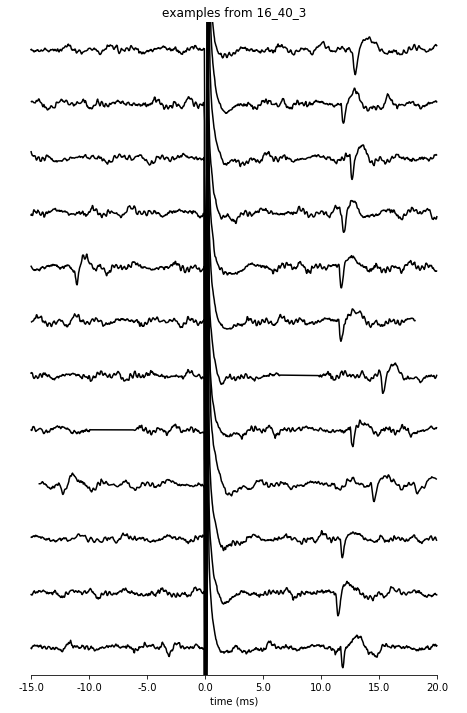

In [19]:
before_t=0.015
after_t=0.02

# get the stimulation events
min_thresh = 1.5
stim_idx, _ = find_peaks(-voltage, height=min_thresh, distance=10000)
stim_idx = stim_idx[1:-1]

n_stim = stim_idx[ex_stim].shape[0]
f, ax = plt.subplots(1, 1, figsize=(8, n_stim))
for i, s_idx in enumerate(stim_idx[ex_stim]):
    # define the time window
    start_t = timestamps[s_idx] - before_t
    end_t = timestamps[s_idx] + after_t
    start_idx = np.argmin(np.abs(timestamps - start_t))
    end_idx = np.argmin(np.abs(timestamps - end_t))
    
    # align to 0
    t_pts = timestamps[start_idx:end_idx].copy()
    t_pts = t_pts - timestamps[s_idx]

    # plot each trace shifted vertically from the others
    ax.plot(t_pts, voltage[start_idx:end_idx] - i*0.5, 'k')

# ticks, lims, labels  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_ylim([(-n_stim + 0.5)*0.5, 0.25])

ax.spines['bottom'].set_bounds(-before_t, after_t)
ax.set_xticks(np.arange(-before_t, after_t + 0.005, 0.005))
ax.set_xticklabels(np.arange(-before_t*1000, after_t*1000 + 5, 5))
ax.set_xlabel('time (ms)')

ax.set_title(f'examples from {ex_session[15:22]}')

plt.show()